In [ ]:
# import pandas as pd
# import jieba
# data = pd.read_csv('product_comments.csv')
# data = data[(data['label']!=2)]

In [8]:
import pandas as pd
import jieba

# 加载数据，并删除中性评论
data = pd.read_csv('product_comments.csv')
data = data[(data['label']!=2)]

# 中文分词
data['seg_words'] = data['review'].apply(lambda x: ' '.join(jieba.cut(x)))


Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\ALIENW~1\AppData\Local\Temp\jieba.cache
Loading model cost 0.577 seconds.
Prefix dict has been built successfully.


In [9]:
data

,review,label,seg_words
2698,笔记本电脑今天到了 一下课就去领了 很好用，才两天就拿到手了，物流很快，也很好看，外观很酷，...,3,笔记本电脑 今天 到 了 一下 课 就 去 领 了 很 好 用 ， 才 两天 就 拿...
2699,之前纠结了好久要不要买拯救者 喜欢这个电脑外观。轻薄 高端。咬咬牙买了 今天到了 果然没...,3,之前 纠结 了 好久 要 不要 买 拯救 者 喜欢 这个 电脑 外观 。 轻薄 ...
2700,拿到货了，发货速度比较快，哈哈哈特别激动，感觉打开，宝贝真的很不错，外观比较精美，与卖家描述...,3,拿到 货 了 ， 发货 速度 比较 快 ， 哈哈哈 特别 激动 ， 感觉 打开 ， 宝贝 真...
2701,外形外观：外观非常有质感，好看。，画面品质：画质很高工作起来眼睛很舒服。，快递发货迅速，还送...,3,外形 外观 ： 外观 非常 有 质感 ， 好看 。 ， 画面 品质 ： 画质 很 高 工作 ...
2702,包装保护很好。开机速度也不错。一直很看好拯救者 真的非常的帅气?，包装保护：很好，外形外观：...,3,包装 保护 很 好 。 开机 速度 也 不错 。 一直 很 看好 拯救 者 真的 非常 ...
...,...,...,...
11337,这个鼠标灵敏不太好,1,这个 鼠标 灵敏 不太好
11338,我只能说千万别在这家店买，价格极不稳定，刚买完货还没有收到马上降价200元，买之前看宣传图写...,1,我 只能 说 千万别 在 这家 店买 ， 价格 极 不 稳定 ， 刚买 完货 还 没有 收到...
11339,插头都是歪的,1,插头 都 是 歪 的
11340,客服就是废物，根本解决不了问题！只会糊弄消费者！,1,客服 就是 废物 ， 根本 解决不了 问题 ！ 只会 糊弄 消费者 ！


In [10]:
import sklearn
print(sklearn.__version__)

1.9.1


In [15]:
import numpy as np

In [11]:
#获取停用词
with open(r'cn-stopwords.txt', encoding='utf-8') as file:
    stop_words = [x.strip() for x in file.readlines()]

#数据集拆分为语料、标签
seg_words = data['seg_words'].tolist()
labels = data['label'].tolist()

from sklearn.feature_extraction.text import TfidfVectorizer
# 初始化TFIV对象，去停用词
tfv = TfidfVectorizer(stop_words=stop_words)  

tfv.fit(seg_words)
X_all = tfv.transform(seg_words)

d:\python\python3.12\Lib\site-packages\sklearn\feature_extraction\text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['lex', '①①', '①②', '①③', '①④', '①⑤', '①⑥', '①⑦', '①⑧', '①⑨', '①ａ', '①ｂ', '①ｃ', '①ｄ', '①ｅ', '①ｆ', '①ｇ', '①ｈ', '①ｉ', '①ｏ', '②①', '②②', '②③', '②④', '②⑤', '②⑥', '②⑦', '②⑧', '②⑩', '②ａ', '②ｂ', '②ｄ', '②ｅ', '②ｆ', '②ｇ', '②ｈ', '②ｉ', '②ｊ', '③①', '③⑩', '③ａ', '③ｂ', '③ｃ', '③ｄ', '③ｅ', '③ｆ', '③ｇ', '③ｈ', '④ａ', '④ｂ', '④ｃ', '④ｄ', '④ｅ', '⑤ａ', '⑤ｂ', '⑤ｄ', '⑤ｅ', '⑤ｆ', '１２', 'ｌｉ', 'ｚｘｆｉｔｌ'] not in stop_words.
  warnings.warn(


In [12]:
# 特征选择
# chi2卡方检验，卡方打分，挑出相关性最高的前100个特征
from sklearn.feature_selection import SelectKBest, chi2
# 卡方检验来选择100个最佳特征
select_feature_model = SelectKBest(chi2, k=100)
# 减少特征的数量，达到降维的效果，从而使模型的方法能力更强，降低过拟合的风险
X_all = select_feature_model.fit_transform(X_all, labels)

In [ ]:
# 切分测试集、训练集
# train_test_split数据集划分，文本特征拆分成25%/75%测试集和训练集，random_state=0随机种子，保证每次划分的结果一致
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X_all, labels, random_state=0, test_size=0.25)

# 使用 MultinomialNB 函数训练(多项式朴素贝叶斯文本分类器)
from sklearn.naive_bayes import MultinomialNB
model_NB = MultinomialNB()
model_NB.fit(x_train, y_train)

from sklearn.model_selection import cross_val_score

# 评估预测性能，减少过拟合
# cv=1010折交叉验证，训练集切为10份轮流9份训练1份验证，循环10次；cross_val_score交叉验证；以AUC作为评估指标，计算10折交叉验证的平均得分
print("贝叶斯分类器10折交叉验证得分: ", np.mean(cross_val_score(model_NB, x_train, y_train, cv=10, scoring='roc_auc')))

贝叶斯分类器10折交叉验证得分:  0.9818124065016993


In [17]:
# 生成混淆矩阵，计算准确率和召回率
from sklearn.metrics import confusion_matrix, precision_score, recall_score
y_predict = model_NB.predict(x_test)
cm = confusion_matrix(y_test, y_predict)
print("混淆矩阵")
print(cm)

precision_sk = precision_score(y_true=y_test, y_pred=y_predict, pos_label=3)
recall_sk = recall_score(y_true=y_test, y_pred=y_predict, pos_label=3)
# :.2f保留两位小数，（f-string格式化字符串）用于格式化输出
print(f"准确率：{precision_sk:.2f}")
print(f"召回率：{recall_sk:.2f}")

混淆矩阵
[[ 374  304]
 [   0 1483]]
准确率：0.83
召回率：1.00


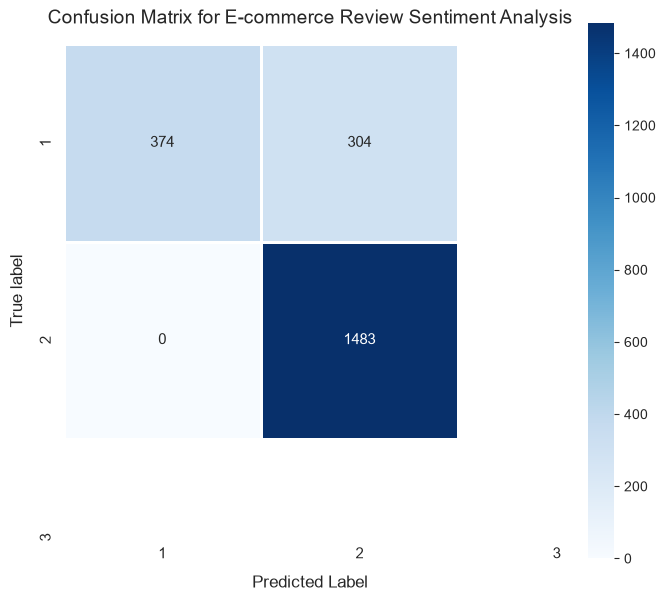

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 中文设置
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

sns.set_style("white")

plt.figure(figsize=(7,7))
ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    square=True,
    linewidths=0.8,
    annot_kws={"size":11},
    xticklabels=["1","2","3"], # 3个类别：差评、中评、好评
    yticklabels=["1","2","3"],
    cbar_kws={"shrink":0.8}
)

ax.set_xlabel("Predicted Label", fontsize=12, labelpad=10)
ax.set_ylabel("True label", fontsize=12, labelpad=10)
ax.set_title("Confusion Matrix for E-commerce Review Sentiment Analysis", fontsize=14, pad=15)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()